In [5]:
import pandas as pd
data = pd.read_csv('imputed_data.csv')
head = data.head()
head

,loan_amnt,verification_status,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,debt_settlement_flag,...,total_acc,loan_paid,has_imputed_values,monthly_income,payment_to_income_ratio,earliest_cr_line_date,credit_age_years,payment_ratio_to_loan,loan_to_income_ratio,fico_score
0,8000,Source Verified,0.0,0.0,148879.0,41401.0,25300.0,33679.0,Cash,N,...,24.0,1,0,14166.666667,0.018606,2004-12-01,20.281999,0.032947,0.047059,739
1,12750,Verified,0.0,0.0,104074.0,79717.0,0.0,98374.0,Cash,N,...,27.0,1,0,6250.000000,0.067749,2003-11-01,21.366188,0.033210,0.170000,743
2,12000,Source Verified,0.0,0.0,23930.0,16536.0,8800.0,14130.0,Cash,N,...,13.0,0,0,5000.000000,0.083916,2001-10-01,23.449692,0.034965,0.200000,662
3,20000,Verified,0.0,0.0,15800.0,11510.0,8700.0,0.0,Cash,N,...,18.0,1,0,4000.000000,0.133837,1997-08-01,27.616701,0.026767,0.416667,586
4,30000,Not Verified,1.0,0.0,54683.0,26857.0,7500.0,44583.0,Cash,N,...,13.0,0,0,2083.333333,0.471658,1990-03-01,35.036277,0.032754,1.200000,503


In [6]:
# get monthly income

data["monthly_income"] = data.annual_inc/12
data[["monthly_income", "annual_inc"]]


,monthly_income,annual_inc
0,14166.666667,170000.0
1,6250.000000,75000.0
2,5000.000000,60000.0
3,4000.000000,48000.0
4,2083.333333,25000.0
...,...,...
209995,9688.500000,116262.0
209996,16666.666667,200000.0
209997,6378.000000,76536.0
209998,11583.333333,139000.0


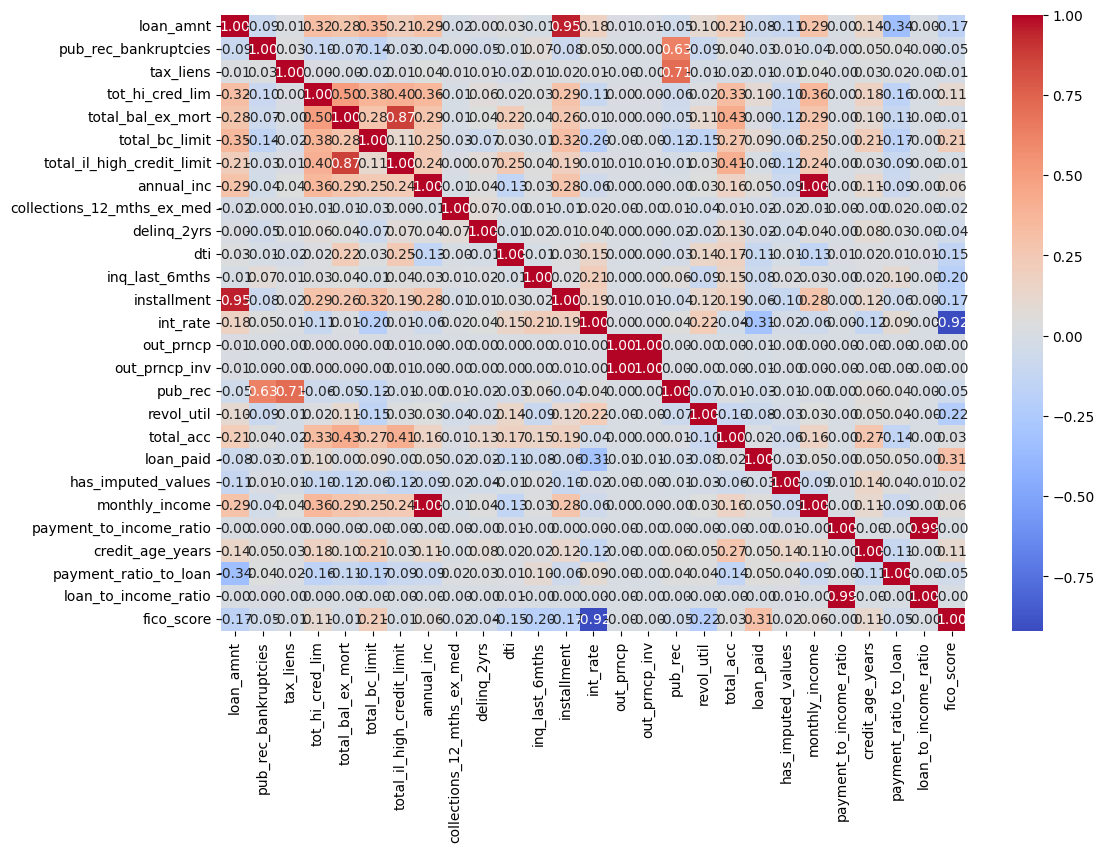

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
#Multicolinearity Analysis
#Create a correlation matrix of numeric variables 
cor_matrix = data.corr(numeric_only=True)
#print(cor_matrix)

#Display a heatmap of the correlations
plt.figure(figsize=(12,8))
sns.heatmap(cor_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [8]:
import pandas as pd
import numpy as np
from datetime import datetime

# Create the four requested features
def create_features(df):
    # 1. Payment to income ratio
    # HAD ISSUE WITH MONTHLY INCOME BEING 0 SO 
# Replace both zeros and NaNs with median value
    median_income = df['monthly_income'].replace(0, np.nan).median()
    df['monthly_income'] = df['monthly_income'].replace(0, median_income)
    
    # Handle annual income
    median_annual_inc = df['annual_inc'].replace(0, np.nan).median()
    df['annual_inc'] = df['annual_inc'].replace(0, median_annual_inc)
    
    
    # 2. Credit age (in years)
    # Convert earliest_cr_line to datetime and calculate age
    df['earliest_cr_line_date'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
    current_date = datetime.now()
    df['credit_age_years'] = ((current_date - df['earliest_cr_line_date']).dt.days / 365.25)
    
    # 4. Loan amount to income ratio
    df['loan_to_income_ratio'] = df['loan_amnt'] / df['annual_inc']
    
    # Create dummy variables for home ownership
    df['home_ownership_RENT'] = (df['home_ownership'] == 'RENT').astype(int)
    df['home_ownership_MORTGAGE'] = (df['home_ownership'] == 'MORTGAGE').astype(int)
    
    return df

# Apply the function
data = create_features(data)

In [9]:
# Save df to CSV with UTF-8 encoding
data.to_csv('feature_data.csv', index=False, encoding='utf-8')

# Verify the file was created
import os
print(f"File saved to: {os.getcwd()}/feature_data.csv")
print(f"File exists: {os.path.exists('feature_data.csv')}")
print(f"File size: {os.path.getsize('feature_data.csv') / (1024*1024):.2f} MB")

File saved to: c:\CWRU\risk_modeling/feature_data.csv
File exists: True
File size: 58.69 MB


# Apply Process of Feature Selection
- sort feature by business purpose and var type
- univariate analysis (continous var)
- univariate analysis (categorical var)
- IV calc
- Mulitollinearity Check
- VIF calc

In [10]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
# Try to import statsmodels, or install it if missing
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except ImportError:
    print("Installing statsmodels package...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels"])
    from statsmodels.stats.outliers_influence import variance_inflation_factor

In [11]:
# Load the data (replace with your actual data path)
df = pd.read_csv('feature_data.csv')

# Check data shape and basic info
print(f"Dataset shape: {df.shape}")
print("\nSample of the data:")
display(df.head())

# Verify target variable
print("\nTarget variable distribution:")
print(df['loan_paid'].value_counts(normalize=True))

Dataset shape: (210000, 40)

Sample of the data:


,loan_amnt,verification_status,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,debt_settlement_flag,...,has_imputed_values,monthly_income,payment_to_income_ratio,earliest_cr_line_date,credit_age_years,payment_ratio_to_loan,loan_to_income_ratio,fico_score,home_ownership_RENT,home_ownership_MORTGAGE
0,8000,Source Verified,0.0,0.0,148879.0,41401.0,25300.0,33679.0,Cash,N,...,0,14166.666667,0.018606,2004-12-01,20.295688,0.032947,0.047059,739,0,0
1,12750,Verified,0.0,0.0,104074.0,79717.0,0.0,98374.0,Cash,N,...,0,6250.000000,0.067749,2003-11-01,21.379877,0.033210,0.170000,743,1,0
2,12000,Source Verified,0.0,0.0,23930.0,16536.0,8800.0,14130.0,Cash,N,...,0,5000.000000,0.083916,2001-10-01,23.463381,0.034965,0.200000,662,1,0
3,20000,Verified,0.0,0.0,15800.0,11510.0,8700.0,0.0,Cash,N,...,0,4000.000000,0.133837,1997-08-01,27.630390,0.026767,0.416667,586,0,0
4,30000,Not Verified,1.0,0.0,54683.0,26857.0,7500.0,44583.0,Cash,N,...,0,2083.333333,0.471658,1990-03-01,35.049966,0.032754,1.200000,503,1,0



Target variable distribution:
loan_paid
0    0.500152
1    0.499848
Name: proportion, dtype: float64


In [12]:
# Step 1: Business-Driven Initial Selection
# Categorize variables by business function as defined in the documentation

# I REMOVED LC OUTPUT VS# ANALYZING THE CONTINOUS VARS!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# proportion_of_defaults: This shows what percentage of all defaults across the entire dataset occur in each decile. It answers "Where are the defaults concentrated?"
# default_rate: This would show the percentage of observations within each decile that defaulted. It answers "How risky is this decile?"
def analyze_by_deciles(df, var, target):
    # Create deciles
    df_decile = df[[var, target]].copy()
    
    try:
        # First create the bins without labels to see how many we get
        temp_decile = pd.qcut(df[var], 10, duplicates='drop')
        num_bins = temp_decile.cat.categories.size
        
        # Now create the deciles with the correct number of labels
        df_decile['decile'] = pd.qcut(df[var], num_bins, labels=range(1, num_bins+1), duplicates='drop')
        
        # Get the bin edges to understand what each decile represents
        bin_edges = pd.qcut(df[var], num_bins, duplicates='drop', retbins=True)[1]
        
        # Create range labels for each decile
        range_labels = []
        for i in range(len(bin_edges)-1):
            range_labels.append(f"{bin_edges[i]:.2f} to {bin_edges[i+1]:.2f}")
        
        # Calculate statistics by decile
        decile_stats = df_decile.groupby('decile').agg(
            count=pd.NamedAgg(column=target, aggfunc='count'),
            num_defaults=pd.NamedAgg(column=target, aggfunc='sum')
        )
        
        # Calculate proportion of total defaults
        total_defaults = decile_stats['num_defaults'].sum()
        decile_stats['proportion_of_defaults'] = decile_stats['num_defaults'] / total_defaults
        decile_stats['default_rate'] = decile_stats['num_defaults'] / decile_stats['count']

        # Add the range information to the statistics
        decile_stats['range'] = range_labels
        
        # Print decile information
        print(f"\nDecile Statistics for {var} ({num_bins} bins created):")
        for i, row in decile_stats.iterrows():
            print(f"Decile {i}: {row['range']} - Count: {row['count']}, "
                    f"Number of Defaults: {row['num_defaults']}, "
                    f"Default Rate: {row['default_rate']:.2%}, "
                    f"Proportion of Total Defaults: {row['proportion_of_defaults']:.2%}")
        
        # Plot
        plt.figure(figsize=(12, 7))
        ax = sns.barplot(x=decile_stats.index.astype(str), y='proportion_of_defaults', data=decile_stats)
        plt.title(f"Proportion of Total Defaults by Decile for {var}")
        plt.xlabel("Decile (Higher = Higher Values)")
        plt.ylabel("Proportion of Total Defaults")
        
        # Add labels to the bars
        for i, p in enumerate(ax.patches):
            ax.annotate(f"{decile_stats['proportion_of_defaults'].iloc[i]:.2%}", 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='bottom')
        
        # Add a note about the decile ordering
        plt.figtext(0.5, 0.01, f"Decile 1: {range_labels[0]} to Decile {num_bins}: {range_labels[-1]}", 
                   ha='center', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        return decile_stats
        
    except Exception as e:
        print(f"Could not analyze {var} by deciles: {str(e)}")
        return None



# Financial Variables
financial_vars = [
    'loan_amnt', 'out_prncp', 'out_prncp_inv',
    'annual_inc', 'dti', 'total_acc', 'total_bal_ex_mort', 'total_bc_limit',
    'total_il_high_credit_limit', 'tot_hi_cred_lim', 'revol_util'
]

# Borrower Information Variables
borrower_info_vars = [
    'verification_status', 'emp_length', 'home_ownership_RENT', 'home_ownership_MORTGAGE', 'credit_age_years',
]

# Credit History Variables
credit_history_vars = [
    'inq_last_6mths', 'pub_rec', 'pub_rec_bankruptcies', 'tax_liens',
    'collections_12_mths_ex_med', 'delinq_2yrs'
]

# Loan Status Variables (excluding the target variable)
loan_status_vars = [
    'term', 'purpose', 'disbursement_method', 'last_pymnt_d', 'debt_settlement_flag'
]

# Target variable
target_var = 'loan_paid'

# Combine all predictor variables
all_predictors = financial_vars + borrower_info_vars + credit_history_vars + loan_status_vars

# Print the categories and the number of variables in each
print(f"Financial Variables ({len(financial_vars)}): {financial_vars}")
print(f"Borrower Information Variables ({len(borrower_info_vars)}): {borrower_info_vars}")
print(f"Credit History Variables ({len(credit_history_vars)}): {credit_history_vars}")
print(f"Loan Status Variables ({len(loan_status_vars)}): {loan_status_vars}")
print(f"Total Predictor Variables: {len(all_predictors)}")

Financial Variables (11): ['loan_amnt', 'out_prncp', 'out_prncp_inv', 'annual_inc', 'dti', 'total_acc', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit', 'tot_hi_cred_lim', 'revol_util']
Borrower Information Variables (5): ['verification_status', 'emp_length', 'home_ownership_RENT', 'home_ownership_MORTGAGE', 'credit_age_years']
Credit History Variables (6): ['inq_last_6mths', 'pub_rec', 'pub_rec_bankruptcies', 'tax_liens', 'collections_12_mths_ex_med', 'delinq_2yrs']
Loan Status Variables (5): ['term', 'purpose', 'disbursement_method', 'last_pymnt_d', 'debt_settlement_flag']
Total Predictor Variables: 27


In [13]:
# Helper function to check if a variable is numeric
def is_numeric(df, col):
    return pd.api.types.is_numeric_dtype(df[col])

# Identify continuous and categorical variables
# CHECKING FOR OVER 25 UNIQUE NUMERICAL VALUES. IF BELOW TEN THEN THAT SHIT IS CATEGORICAL LIKE THE NON NUMERIC VARS
continuous_vars = [col for col in all_predictors if is_numeric(df, col) and df[col].nunique() > 25]
categorical_vars = [col for col in all_predictors if col not in continuous_vars]

print(f"Continuous Variables ({len(continuous_vars)}):")
for var in continuous_vars:
    print(f"  - {var}")
    
print(f"\nCategorical Variables ({len(categorical_vars)}):")
for var in categorical_vars:
    print(f"  - {var}")

# Prepare a dictionary to store analysis results
analysis_results = {
    'correlation': {},
    'iv': {},
    'categorical_stats': {},
    'decile_stats': {}
}

Continuous Variables (10):
  - loan_amnt
  - annual_inc
  - dti
  - total_acc
  - total_bal_ex_mort
  - total_bc_limit
  - total_il_high_credit_limit
  - tot_hi_cred_lim
  - revol_util
  - credit_age_years

Categorical Variables (17):
  - out_prncp
  - out_prncp_inv
  - verification_status
  - emp_length
  - home_ownership_RENT
  - home_ownership_MORTGAGE
  - inq_last_6mths
  - pub_rec
  - pub_rec_bankruptcies
  - tax_liens
  - collections_12_mths_ex_med
  - delinq_2yrs
  - term
  - purpose
  - disbursement_method
  - last_pymnt_d
  - debt_settlement_flag



Analyzing loan_amnt:
Correlation with loan_paid: -0.0781


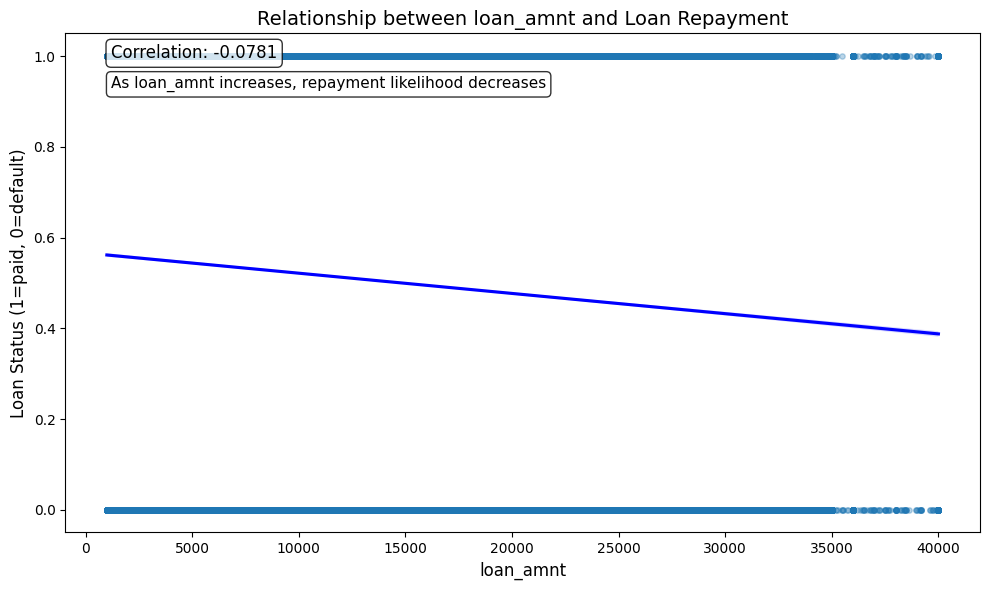

C:\Users\chris\AppData\Local\Temp\ipykernel_41124\1358821203.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_stats = df_decile.groupby('decile').agg(



Decile Statistics for loan_amnt (10 bins created):
Decile 1: 1000.00 to 5000.00
  Count: 26113
  Paid Loans: 14814 (56.73%)
  Defaults: 11299 (43.27%)
  Proportion of Total Paid Loans: 14.11%
Decile 2: 5000.00 to 7000.00
  Count: 17304
  Paid Loans: 9782 (56.53%)
  Defaults: 7522 (43.47%)
  Proportion of Total Paid Loans: 9.32%
Decile 3: 7000.00 to 9450.00
  Count: 19610
  Paid Loans: 10706 (54.59%)
  Defaults: 8904 (45.41%)
  Proportion of Total Paid Loans: 10.20%
Decile 4: 9450.00 to 10625.00
  Count: 21017
  Paid Loans: 10753 (51.16%)
  Defaults: 10264 (48.84%)
  Proportion of Total Paid Loans: 10.24%
Decile 5: 10625.00 to 12900.00
  Count: 20977
  Paid Loans: 10298 (49.09%)
  Defaults: 10679 (50.91%)
  Proportion of Total Paid Loans: 9.81%
Decile 6: 12900.00 to 15000.00
  Count: 21547
  Paid Loans: 10598 (49.19%)
  Defaults: 10949 (50.81%)
  Proportion of Total Paid Loans: 10.10%
Decile 7: 15000.00 to 18700.00
  Count: 20473
  Paid Loans: 9354 (45.69%)
  Defaults: 11119 (54.31%)
 

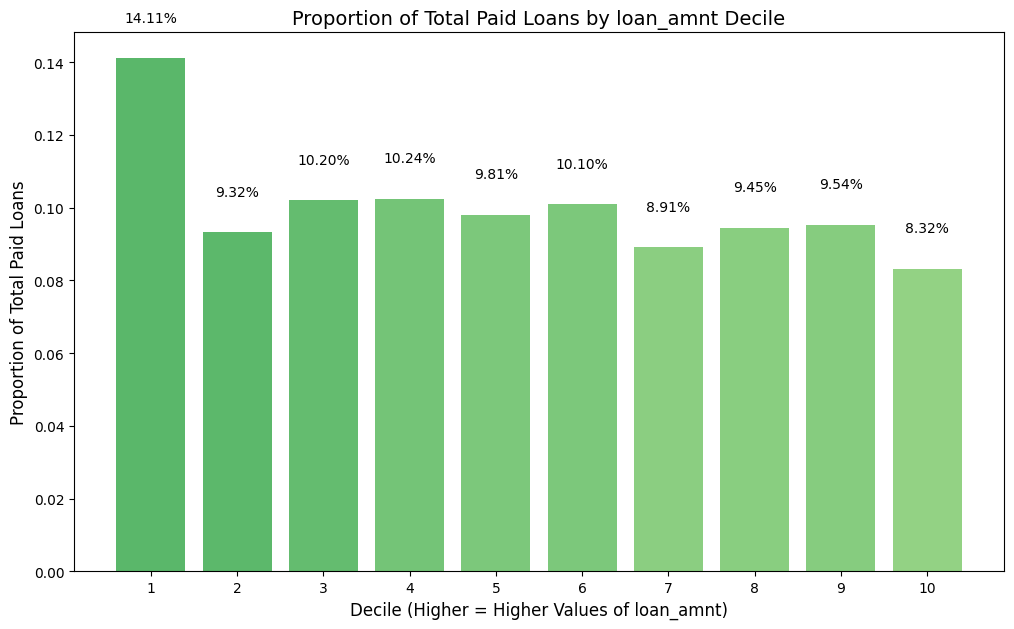

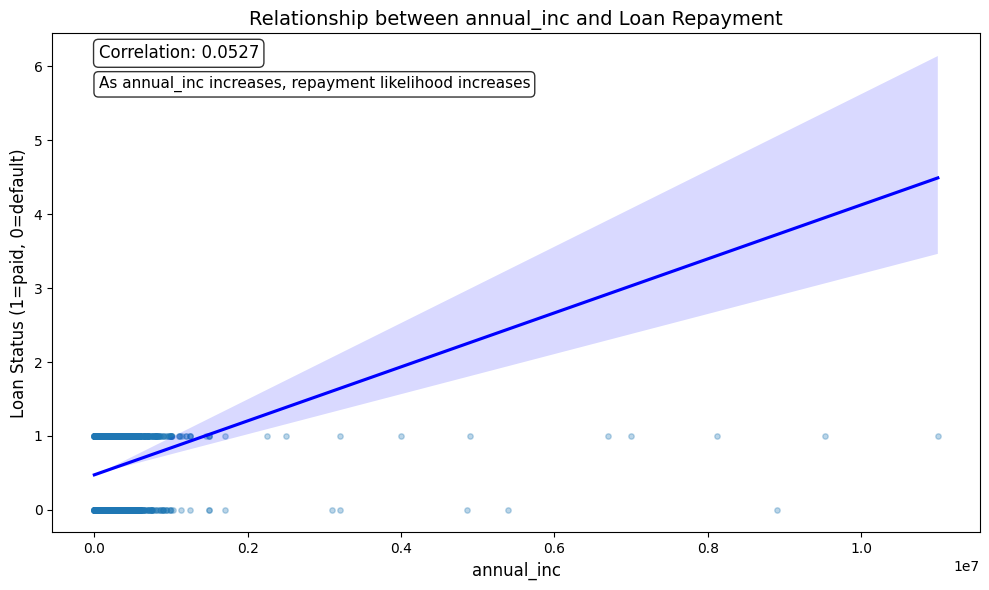

C:\Users\chris\AppData\Local\Temp\ipykernel_41124\1358821203.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_stats = df_decile.groupby('decile').agg(



Decile Statistics for annual_inc (10 bins created):
Decile 1: 1.00 to 33000.00
  Count: 21502
  Paid Loans: 9446 (43.93%)
  Defaults: 12056 (56.07%)
  Proportion of Total Paid Loans: 9.00%
Decile 2: 33000.00 to 41000.00
  Count: 21134
  Paid Loans: 9694 (45.87%)
  Defaults: 11440 (54.13%)
  Proportion of Total Paid Loans: 9.24%
Decile 3: 41000.00 to 49000.00
  Count: 20939
  Paid Loans: 9771 (46.66%)
  Defaults: 11168 (53.34%)
  Proportion of Total Paid Loans: 9.31%
Decile 4: 49000.00 to 55000.00
  Count: 22088
  Paid Loans: 10455 (47.33%)
  Defaults: 11633 (52.67%)
  Proportion of Total Paid Loans: 9.96%
Decile 5: 55000.00 to 62700.00
  Count: 19365
  Paid Loans: 9344 (48.25%)
  Defaults: 10021 (51.75%)
  Proportion of Total Paid Loans: 8.90%
Decile 6: 62700.00 to 71000.00
  Count: 21154
  Paid Loans: 10563 (49.93%)
  Defaults: 10591 (50.07%)
  Proportion of Total Paid Loans: 10.06%
Decile 7: 71000.00 to 81200.00
  Count: 20826
  Paid Loans: 10642 (51.10%)
  Defaults: 10184 (48.90%)


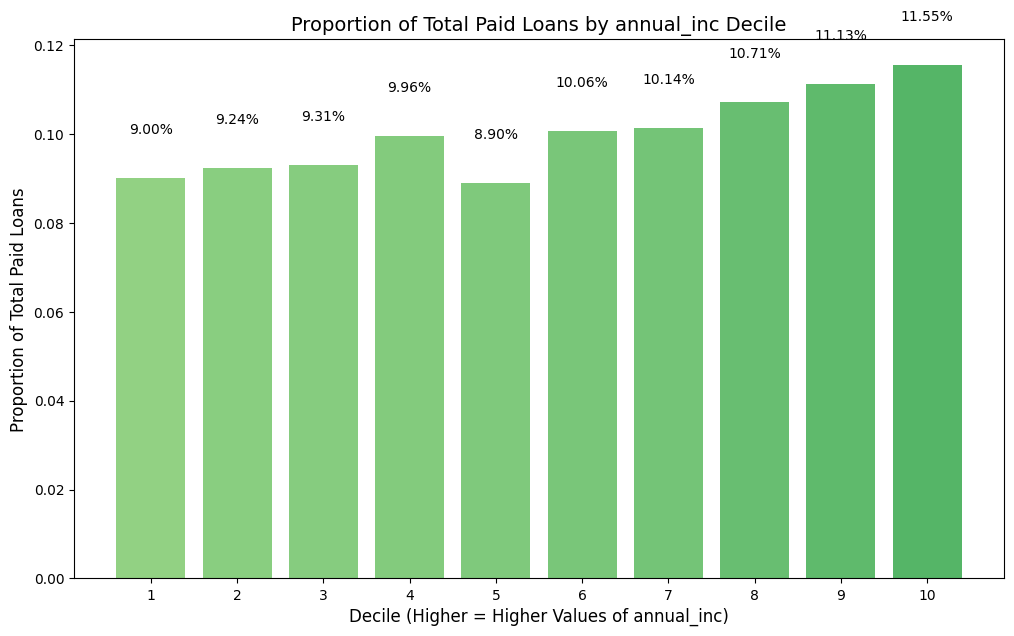

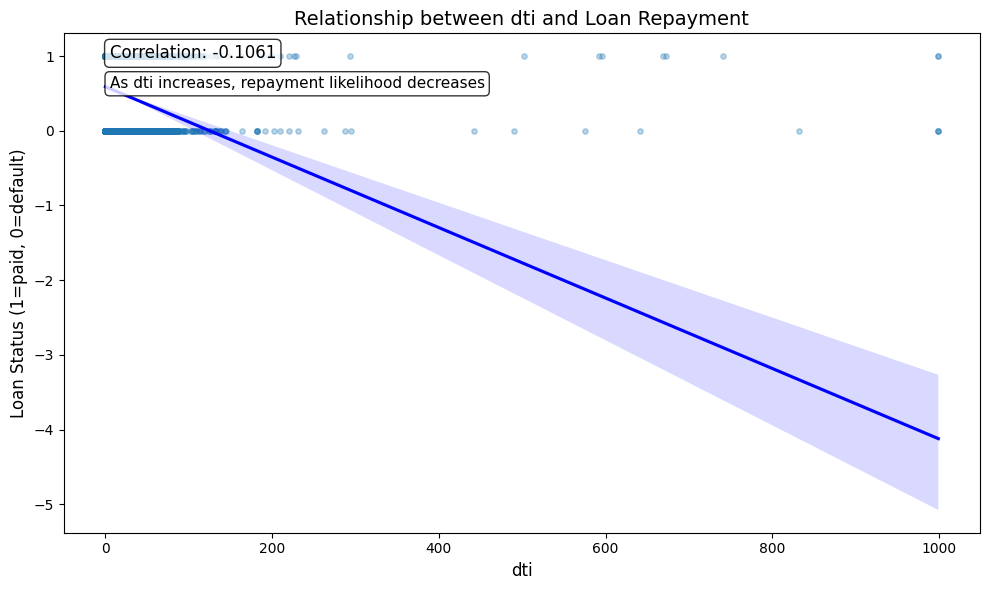

C:\Users\chris\AppData\Local\Temp\ipykernel_41124\1358821203.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_stats = df_decile.groupby('decile').agg(



Decile Statistics for dti (10 bins created):
Decile 1: 0.00 to 7.71
  Count: 21040
  Paid Loans: 12471 (59.27%)
  Defaults: 8569 (40.73%)
  Proportion of Total Paid Loans: 11.88%
Decile 2: 7.71 to 11.05
  Count: 20990
  Paid Loans: 12078 (57.54%)
  Defaults: 8912 (42.46%)
  Proportion of Total Paid Loans: 11.51%
Decile 3: 11.05 to 13.69
  Count: 21023
  Paid Loans: 11763 (55.95%)
  Defaults: 9260 (44.05%)
  Proportion of Total Paid Loans: 11.21%
Decile 4: 13.69 to 16.05
  Count: 20955
  Paid Loans: 11257 (53.72%)
  Defaults: 9698 (46.28%)
  Proportion of Total Paid Loans: 10.72%
Decile 5: 16.05 to 18.41
  Count: 21081
  Paid Loans: 11012 (52.24%)
  Defaults: 10069 (47.76%)
  Proportion of Total Paid Loans: 10.49%
Decile 6: 18.41 to 20.83
  Count: 20974
  Paid Loans: 10480 (49.97%)
  Defaults: 10494 (50.03%)
  Proportion of Total Paid Loans: 9.98%
Decile 7: 20.83 to 23.47
  Count: 20947
  Paid Loans: 9913 (47.32%)
  Defaults: 11034 (52.68%)
  Proportion of Total Paid Loans: 9.44%
Decil

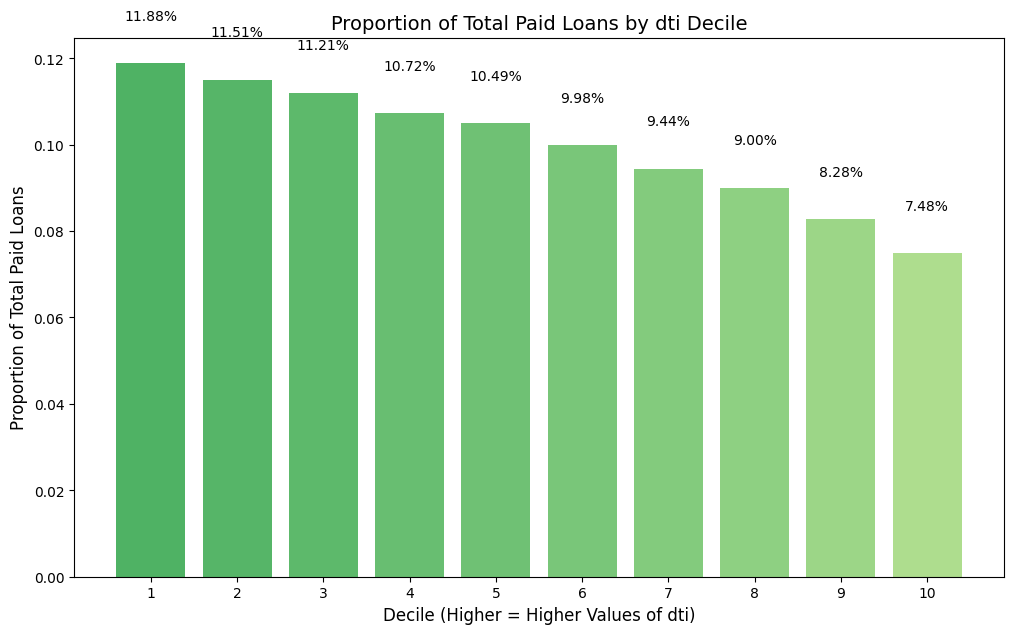

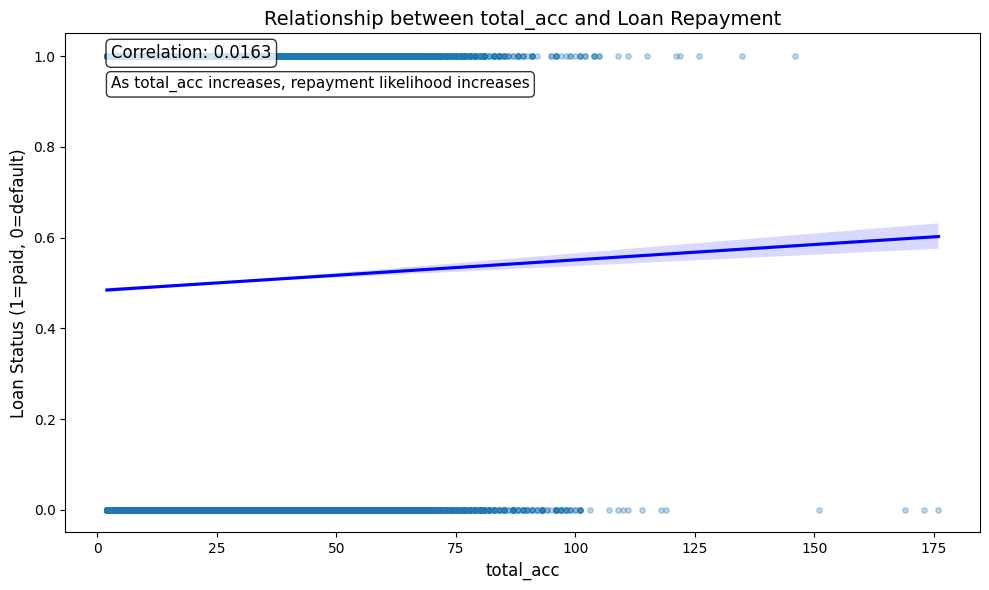

C:\Users\chris\AppData\Local\Temp\ipykernel_41124\1358821203.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_stats = df_decile.groupby('decile').agg(



Decile Statistics for total_acc (10 bins created):
Decile 1: 2.00 to 11.00
  Count: 23124
  Paid Loans: 11048 (47.78%)
  Defaults: 12076 (52.22%)
  Proportion of Total Paid Loans: 10.53%
Decile 2: 11.00 to 15.00
  Count: 24976
  Paid Loans: 12136 (48.59%)
  Defaults: 12840 (51.41%)
  Proportion of Total Paid Loans: 11.56%
Decile 3: 15.00 to 18.00
  Count: 22034
  Paid Loans: 10947 (49.68%)
  Defaults: 11087 (50.32%)
  Proportion of Total Paid Loans: 10.43%
Decile 4: 18.00 to 20.00
  Count: 15158
  Paid Loans: 7476 (49.32%)
  Defaults: 7682 (50.68%)
  Proportion of Total Paid Loans: 7.12%
Decile 5: 20.00 to 23.00
  Count: 22540
  Paid Loans: 11403 (50.59%)
  Defaults: 11137 (49.41%)
  Proportion of Total Paid Loans: 10.86%
Decile 6: 23.00 to 26.00
  Count: 20471
  Paid Loans: 10280 (50.22%)
  Defaults: 10191 (49.78%)
  Proportion of Total Paid Loans: 9.79%
Decile 7: 26.00 to 30.00
  Count: 23245
  Paid Loans: 11763 (50.60%)
  Defaults: 11482 (49.40%)
  Proportion of Total Paid Loans: 1

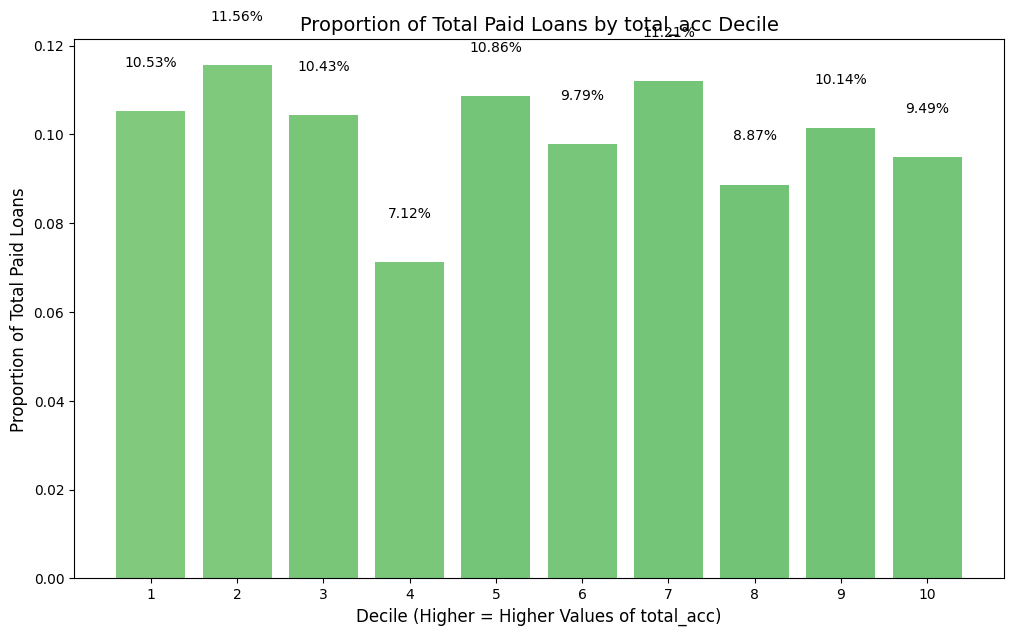

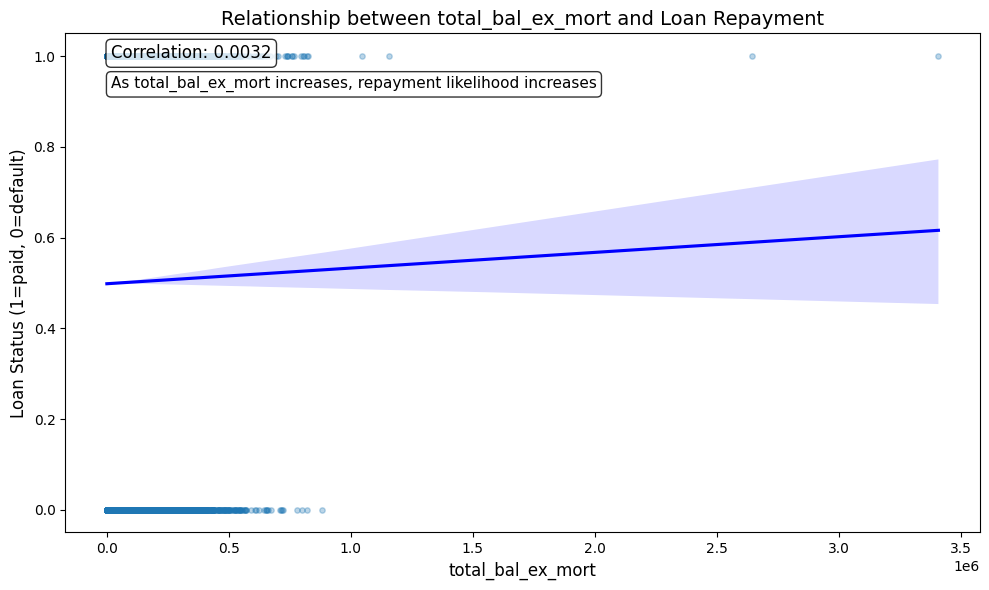

C:\Users\chris\AppData\Local\Temp\ipykernel_41124\1358821203.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_stats = df_decile.groupby('decile').agg(



Decile Statistics for total_bal_ex_mort (10 bins created):
Decile 1: 0.00 to 11405.00
  Count: 21003
  Paid Loans: 10979 (52.27%)
  Defaults: 10024 (47.73%)
  Proportion of Total Paid Loans: 10.46%
Decile 2: 11405.00 to 18442.80
  Count: 20997
  Paid Loans: 10730 (51.10%)
  Defaults: 10267 (48.90%)
  Proportion of Total Paid Loans: 10.22%
Decile 3: 18442.80 to 24847.70
  Count: 21000
  Paid Loans: 10392 (49.49%)
  Defaults: 10608 (50.51%)
  Proportion of Total Paid Loans: 9.90%
Decile 4: 24847.70 to 31475.00
  Count: 21002
  Paid Loans: 10258 (48.84%)
  Defaults: 10744 (51.16%)
  Proportion of Total Paid Loans: 9.77%
Decile 5: 31475.00 to 37467.00
  Count: 24443
  Paid Loans: 12624 (51.65%)
  Defaults: 11819 (48.35%)
  Proportion of Total Paid Loans: 12.03%
Decile 6: 37467.00 to 44260.00
  Count: 17558
  Paid Loans: 8642 (49.22%)
  Defaults: 8916 (50.78%)
  Proportion of Total Paid Loans: 8.23%
Decile 7: 44260.00 to 54568.00
  Count: 20998
  Paid Loans: 10110 (48.15%)
  Defaults: 1088

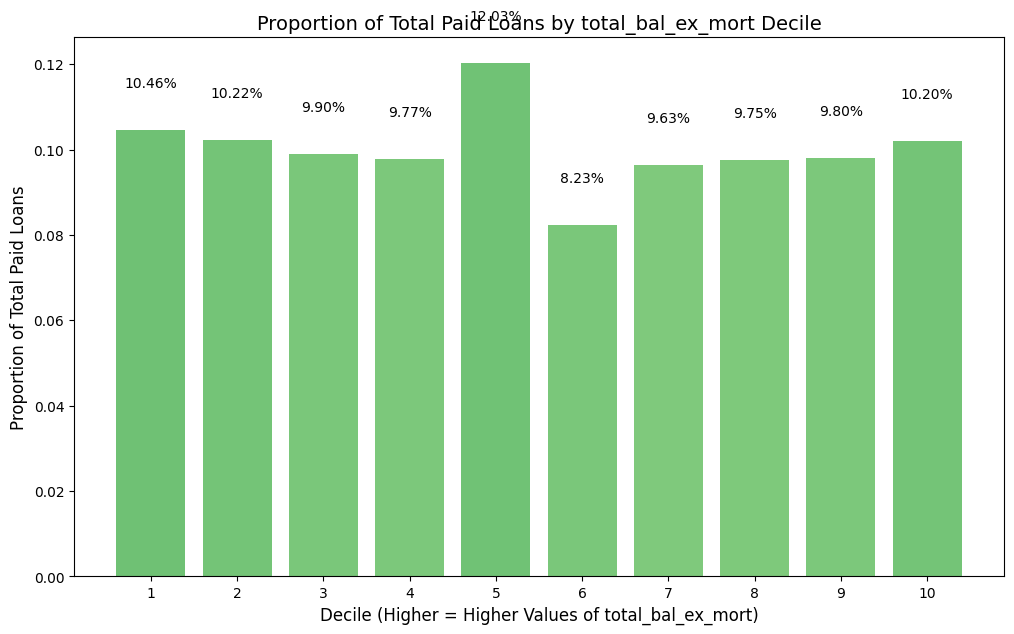

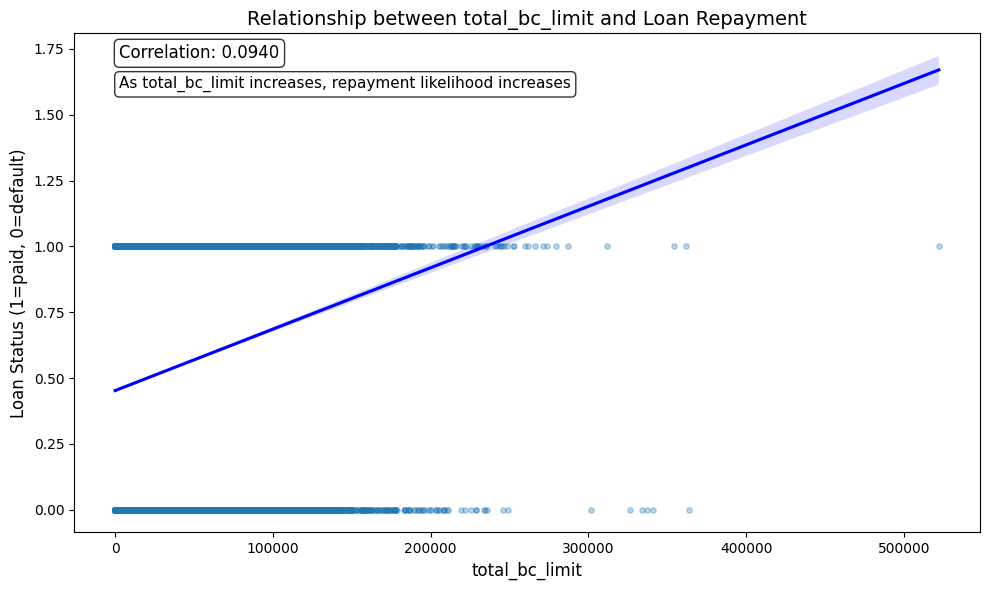

C:\Users\chris\AppData\Local\Temp\ipykernel_41124\1358821203.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_stats = df_decile.groupby('decile').agg(



Decile Statistics for total_bc_limit (10 bins created):
Decile 1: 0.00 to 3800.00
  Count: 21481
  Paid Loans: 9380 (43.67%)
  Defaults: 12101 (56.33%)
  Proportion of Total Paid Loans: 8.94%
Decile 2: 3800.00 to 6300.00
  Count: 20542
  Paid Loans: 9314 (45.34%)
  Defaults: 11228 (54.66%)
  Proportion of Total Paid Loans: 8.87%
Decile 3: 6300.00 to 8800.00
  Count: 21008
  Paid Loans: 9672 (46.04%)
  Defaults: 11336 (53.96%)
  Proportion of Total Paid Loans: 9.21%
Decile 4: 8800.00 to 11500.00
  Count: 21018
  Paid Loans: 9852 (46.87%)
  Defaults: 11166 (53.13%)
  Proportion of Total Paid Loans: 9.39%
Decile 5: 11500.00 to 14300.00
  Count: 24902
  Paid Loans: 12604 (50.61%)
  Defaults: 12298 (49.39%)
  Proportion of Total Paid Loans: 12.01%
Decile 6: 14300.00 to 17500.00
  Count: 17364
  Paid Loans: 8482 (48.85%)
  Defaults: 8882 (51.15%)
  Proportion of Total Paid Loans: 8.08%
Decile 7: 17500.00 to 22500.00
  Count: 20898
  Paid Loans: 10374 (49.64%)
  Defaults: 10524 (50.36%)
  Pr

In [ ]:
# Function to analyze correlation with enhanced visualization
def analyze_correlation(df, var, target):
    """
    Analyze correlation between a variable and the target.
    
    Args:
        df: DataFrame containing the data
        var: The variable to analyze
        target: The target variable (loan_paid where 1=paid, 0=default)
        
    Returns:
        float: Correlation coefficient
    """
    try:
        corr = df[[var, target]].corr().iloc[0, 1]
        print(f"Correlation with {target}: {corr:.4f}")
        
        # Create a more informative visualization with regression line
        plt.figure(figsize=(10, 6))
        
        # Create scatter plot with transparency for overlapping points
        # Use regplot to add regression line
        sns.regplot(x=var, y=target, data=df, scatter_kws={'alpha': 0.3, 's': 15}, 
                  line_kws={'color': 'blue'})
        
        plt.title(f"Relationship between {var} and Loan Repayment", fontsize=14)
        plt.xlabel(var, fontsize=12)
        plt.ylabel(f"Loan Status (1=paid, 0=default)", fontsize=12)
        
        # Add correlation coefficient to the plot
        plt.text(0.05, 0.95, f"Correlation: {corr:.4f}", 
                transform=plt.gca().transAxes, fontsize=12,
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
        
        # Add interpretation note
        if corr > 0:
            interpretation = f"As {var} increases, repayment likelihood increases"
        else:
            interpretation = f"As {var} increases, repayment likelihood decreases"
            
        plt.text(0.05, 0.89, interpretation, 
                transform=plt.gca().transAxes, fontsize=11,
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
        return corr
    except Exception as e:
        print(f"Could not analyze correlation for {var}: {str(e)}")
        return None

# Improved function to analyze by deciles with clearer terminology
def analyze_by_deciles(df, var, target):
    """
    Analyze a variable by dividing it into deciles and examining the relationship with loan repayment.
    
    Args:
        df: DataFrame containing the data
        var: The variable to analyze
        target: The target variable (loan_paid where 1=paid, 0=default)
        
    Returns:
        DataFrame: Statistics by decile
    """
    # Create deciles
    df_decile = df[[var, target]].copy()
    
    try:
        # First create the bins without labels to see how many we get
        temp_decile = pd.qcut(df[var], 10, duplicates='drop')
        num_bins = temp_decile.cat.categories.size
        
        # Now create the deciles with the correct number of labels
        df_decile['decile'] = pd.qcut(df[var], num_bins, labels=range(1, num_bins+1), duplicates='drop')
        
        # Get the bin edges to understand what each decile represents
        bin_edges = pd.qcut(df[var], num_bins, duplicates='drop', retbins=True)[1]
        
        # Create range labels for each decile
        range_labels = []
        for i in range(len(bin_edges)-1):
            range_labels.append(f"{bin_edges[i]:.2f} to {bin_edges[i+1]:.2f}")
        
        # Calculate statistics by decile
        decile_stats = df_decile.groupby('decile').agg(
            count=pd.NamedAgg(column=target, aggfunc='count'),
            num_paid=pd.NamedAgg(column=target, aggfunc='sum')
        )
        
        # Calculate number of defaults
        decile_stats['num_defaults'] = decile_stats['count'] - decile_stats['num_paid']
        
        # Calculate proportion of total paid and rates
        total_paid = decile_stats['num_paid'].sum()
        total_defaults = decile_stats['num_defaults'].sum()
        decile_stats['proportion_of_paid'] = decile_stats['num_paid'] / total_paid
        decile_stats['proportion_of_defaults'] = decile_stats['num_defaults'] / total_defaults
        decile_stats['repayment_rate'] = decile_stats['num_paid'] / decile_stats['count']
        decile_stats['default_rate'] = decile_stats['num_defaults'] / decile_stats['count']

        # Add the range information to the statistics
        decile_stats['range'] = range_labels
        
        # Print decile information with clear labels
        print(f"\nDecile Statistics for {var} ({num_bins} bins created):")
        for i, row in decile_stats.iterrows():
            print(f"Decile {i}: {row['range']}")
            print(f"  Count: {row['count']}")
            print(f"  Paid Loans: {row['num_paid']} ({row['repayment_rate']:.2%})")
            print(f"  Defaults: {row['num_defaults']} ({row['default_rate']:.2%})")
            print(f"  Proportion of Total Paid Loans: {row['proportion_of_paid']:.2%}")
        
        # Create two visualizations: proportion of paid loans and repayment rate
        
        # 1. Proportion of total paid loans plot
        plt.figure(figsize=(12, 7))
        
        # Define a color gradient based on repayment rate (green = higher repayment)
        colors = plt.cm.YlGn(decile_stats['repayment_rate'])
        
        ax = plt.bar(decile_stats.index.astype(str), decile_stats['proportion_of_paid'], color=colors)
        plt.title(f"Proportion of Total Paid Loans by {var} Decile", fontsize=14)
        plt.xlabel("Decile (Higher = Higher Values of " + var + ")", fontsize=12)
        plt.ylabel("Proportion of Total Paid Loans", fontsize=12)
        
        # Add labels to the bars
        for i, p in enumerate(ax):
            height = decile_stats['proportion_of_paid'].iloc[i]
            plt.text(p.get_x() + p.get_width() / 2., height + 0.01,
                   f"{height:.2%}", ha='center', fontsize=10)
        
        # Add a colorbar legend
        sm = plt.cm.ScalarMappable(cmap=plt.cm.YlGn, norm=plt.Normalize(
            decile_stats['repayment_rate'].min(), decile_stats['repayment_rate'].max()))
        sm.set_array([])
        cbar = plt.colorbar(sm)
        cbar.set_label('Repayment Rate', fontsize=10)
        
        # Add a note about the decile ordering
        plt.figtext(0.5, 0.01, f"Decile 1: {range_labels[0]} to Decile {num_bins}: {range_labels[-1]}", 
                   ha='center', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        # 2. Repayment rate plot
        plt.figure(figsize=(12, 7))
        ax = plt.bar(decile_stats.index.astype(str), decile_stats['repayment_rate'], color=colors)
        plt.title(f"Repayment Rate by {var} Decile", fontsize=14)
        plt.xlabel("Decile (Higher = Higher Values of " + var + ")", fontsize=12)
        plt.ylabel("Repayment Rate (% of Loans in Decile that were Paid)", fontsize=12)
        
        # Add labels to the bars
        for i, p in enumerate(ax):
            height = decile_stats['repayment_rate'].iloc[i]
            plt.text(p.get_x() + p.get_width() / 2., height + 0.01,
                   f"{height:.2%}", ha='center', fontsize=10)
        
        # Add a note about the decile ordering
        plt.figtext(0.5, 0.01, f"Decile 1: {range_labels[0]} to Decile {num_bins}: {range_labels[-1]}", 
                   ha='center', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        # 3. Default rate plot (alternative view)
        plt.figure(figsize=(12, 7))
        # Use a red color scheme for default rates
        default_colors = plt.cm.YlOrRd(decile_stats['default_rate'])
        ax = plt.bar(decile_stats.index.astype(str), decile_stats['default_rate'], color=default_colors)
        plt.title(f"Default Rate by {var} Decile", fontsize=14)
        plt.xlabel("Decile (Higher = Higher Values of " + var + ")", fontsize=12)
        plt.ylabel("Default Rate (% of Loans in Decile that Defaulted)", fontsize=12)
        
        # Add labels to the bars
        for i, p in enumerate(ax):
            height = decile_stats['default_rate'].iloc[i]
            plt.text(p.get_x() + p.get_width() / 2., height + 0.01,
                   f"{height:.2%}", ha='center', fontsize=10)
        
        # Add a note about the decile ordering
        plt.figtext(0.5, 0.01, f"Decile 1: {range_labels[0]} to Decile {num_bins}: {range_labels[-1]}", 
                   ha='center', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        return decile_stats
        
    except Exception as e:
        print(f"Could not analyze {var} by deciles: {str(e)}")
        return None

# Process each continuous variable
for var in continuous_vars:
    print(f"\n{'='*50}")
    print(f"Analyzing {var}:")
    print(f"{'='*50}")
    
    # Calculate correlation with target
    corr = analyze_correlation(df, var, target_var)
    analysis_results['correlation'][var] = corr
    
    # Analyze by deciles
    decile_stats = analyze_by_deciles(df, var, target_var)
    analysis_results['decile_stats'][var] = decile_stats